=== Cycle Extraction ===
Normal Train   : 330
Normal Holdout : 145
Abnormal       : 8

=== Normal Cycle Shape Reference ===
Shape RMSE 99.0% threshold : 0.1882
Template Corr 1.0% reference : 0.9817
Normal Holdout Shape FPR          : 0.0138

=== Abnormal Cycle-synchronous Current Shape ===
segment_id  cycle_id  duration_sec  AI2_Current_rms  Shape_RMSE  Template_Corr  H1_share  H2_share  H3_share  Shape_Break
     A0001         1           1.3          97.8139      0.8628         0.6157    0.6604    0.0050    0.0275         True
     A0001         2           1.3         110.1892      1.2401         0.2062    0.6838    0.0317    0.0213         True
     A0006         1           1.5         178.8959      0.5603         0.8379    0.7277    0.0608    0.0553         True
     A0011         1           1.6          52.9194      1.5245        -0.1995    0.1704    0.0696    0.1119         True
     A0011         2           1.6          73.6123      1.2381         0.2088    0.3567    0.2741 

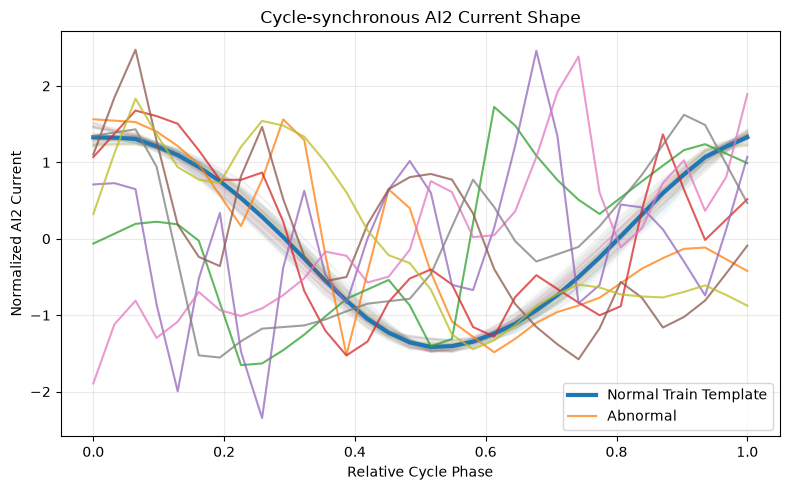

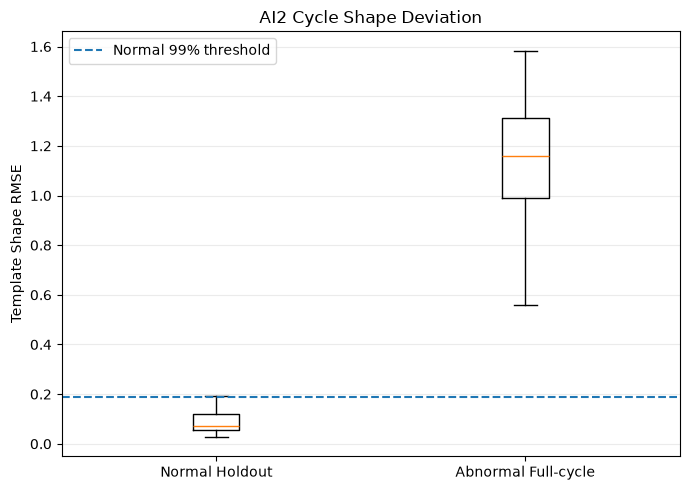

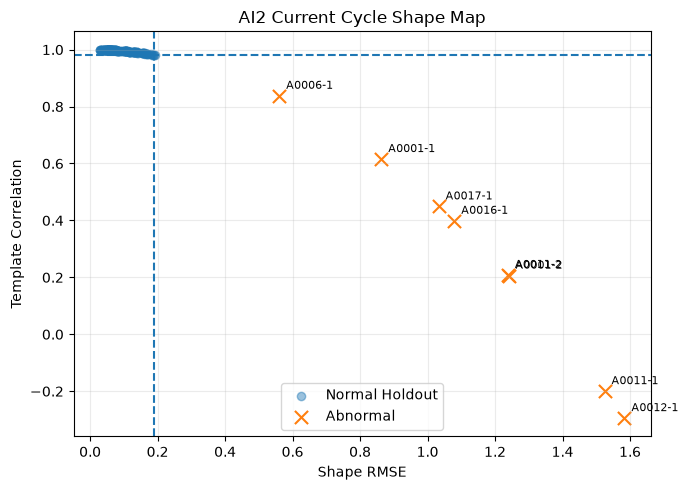


Saved to: c:\Users\astra\Desktop\K_eng\KAMP\05_EDA\05_Physics_Informed\03_Current_Shape_results


In [1]:
# AI2 Current cycle을 상대위상으로 정렬해 Normal cycle shape을 학습한다.
# Cycle별 평균·크기 차이를 제거하고 Normal template과 Shape RMSE/Correlation을 계산한다.
# 저차 cycle harmonic 비율도 보조 특징으로 저장해 파형 구조 변화 여부를 확인한다.
# 보간점은 시각적 비교용 공통 격자이며 새로운 독립 측정값으로 해석하지 않는다.

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

MIN_SEG_ROWS, MIN_PEAK_DIST, N_PHASE = 30, 12, 32
SHAPE_Q = .99


# ------------------------------------------------------------
# 1. 경로 / 기존 Normal Train-Holdout split 재사용
# ------------------------------------------------------------
def find_root():
    starts = [Path.cwd()]
    try: starts.append(Path(__file__).resolve().parent)
    except NameError: pass
    for start in starts:
        for p in [start, *start.parents]:
            if (p / "data/processed/preprocessed_data.csv").exists(): return p
    raise FileNotFoundError("프로젝트 root를 찾지 못했습니다.")

ROOT = find_root()
DATA_PATH = ROOT / "data/processed/preprocessed_data.csv"
PORD_DIR = ROOT / "KAMP/05_EDA/05_Physics_Informed/01_PORD_results"
OUT = ROOT / "KAMP/05_EDA/05_Physics_Informed/03_Current_Shape_results"
OUT.mkdir(parents=True, exist_ok=True)

data = pd.read_csv(DATA_PATH)
train_seg = set(pd.read_csv(PORD_DIR / "normal_train_pord.csv").segment_id.unique())
holdout_seg = set(pd.read_csv(PORD_DIR / "normal_holdout_pord.csv").segment_id.unique())


# ------------------------------------------------------------
# 2. AI2 Full-cycle 추출 + 상대위상 정규화
# ------------------------------------------------------------
def phase_shape(x):
    x = np.asarray(x, float)
    phase_raw, phase_new = np.linspace(0, 1, len(x)), np.linspace(0, 1, N_PHASE)
    y = np.interp(phase_new, phase_raw, x)
    sd = y.std(ddof=1)
    if sd == 0: return None
    return (y - y.mean()) / sd

def extract_cycles(df, source):
    rows, shapes = [], []
    for seg, g in df[df.source == source].groupby("segment_id", sort=False):
        g = g.sort_values("pos_in_seg").reset_index(drop=True)
        if len(g) < MIN_SEG_ROWS: continue

        cur = g.AI2_Current.to_numpy(float)
        sm = pd.Series(cur).rolling(3, center=True, min_periods=1).median().to_numpy()
        prom = max(np.std(sm, ddof=1) * .5, np.finfo(float).eps)
        peaks, _ = find_peaks(sm, distance=MIN_PEAK_DIST, prominence=prom)

        for cid, (s, e) in enumerate(zip(peaks[:-1], peaks[1:]), 1):
            if e - s < MIN_PEAK_DIST: continue
            c = g.iloc[s:e + 1]
            duration = c.elapsed_sec.iloc[-1] - c.elapsed_sec.iloc[0]
            shape = phase_shape(c.AI2_Current)
            if duration <= 0 or shape is None: continue

            rows.append({
                "source": source, "segment_id": seg, "cycle_id": cid,
                "duration_sec": float(duration), "n_samples": len(c),
                "AI2_Current_rms": float(np.sqrt(np.mean(c.AI2_Current.to_numpy(float) ** 2)))
            })
            shapes.append(shape)

    return pd.DataFrame(rows), np.vstack(shapes)

normal_meta, normal_shape = extract_cycles(data, "normal")
abnormal_meta, abnormal_shape = extract_cycles(data, "abnormal")

train_mask = normal_meta.segment_id.isin(train_seg).to_numpy()
holdout_mask = normal_meta.segment_id.isin(holdout_seg).to_numpy()

train_meta, train_shape = normal_meta[train_mask].copy(), normal_shape[train_mask]
holdout_meta, holdout_shape = normal_meta[holdout_mask].copy(), normal_shape[holdout_mask]

print("=== Cycle Extraction ===")
print(f"Normal Train   : {len(train_meta)}")
print(f"Normal Holdout : {len(holdout_meta)}")
print(f"Abnormal       : {len(abnormal_meta)}")


# ------------------------------------------------------------
# 3. Normal Train Cycle Template
# ------------------------------------------------------------
template = train_shape.mean(axis=0)
template = (template - template.mean()) / template.std(ddof=1)

def shape_features(shapes, template):
    rmse = np.sqrt(np.mean((shapes - template) ** 2, axis=1))
    corr = np.array([np.corrcoef(x, template)[0, 1] for x in shapes])

    fft = np.abs(np.fft.rfft(shapes, axis=1))[:, 1:] ** 2
    total = fft.sum(axis=1, keepdims=True) + 1e-12
    share = fft / total

    return pd.DataFrame({
        "Shape_RMSE": rmse, "Template_Corr": corr,
        "H1_share": share[:, 0], "H2_share": share[:, 1], "H3_share": share[:, 2]
    })

train_feat = shape_features(train_shape, template)
holdout_feat = shape_features(holdout_shape, template)
abnormal_feat = shape_features(abnormal_shape, template)

train_meta = pd.concat([train_meta.reset_index(drop=True), train_feat], axis=1)
holdout_meta = pd.concat([holdout_meta.reset_index(drop=True), holdout_feat], axis=1)
abnormal_meta = pd.concat([abnormal_meta.reset_index(drop=True), abnormal_feat], axis=1)


# ------------------------------------------------------------
# 4. Normal Holdout 기준으로 Shape threshold 고정
# ------------------------------------------------------------
RMSE_TH = holdout_meta.Shape_RMSE.quantile(SHAPE_Q)
CORR_REF = holdout_meta.Template_Corr.quantile(1 - SHAPE_Q)

for df in [train_meta, holdout_meta, abnormal_meta]:
    df["Shape_Break"] = df.Shape_RMSE > RMSE_TH
    df["Low_Corr"] = df.Template_Corr < CORR_REF

print("\n=== Normal Cycle Shape Reference ===")
print(f"Shape RMSE {SHAPE_Q:.1%} threshold : {RMSE_TH:.4f}")
print(f"Template Corr {(1-SHAPE_Q):.1%} reference : {CORR_REF:.4f}")
print(f"Normal Holdout Shape FPR          : {holdout_meta.Shape_Break.mean():.4f}")


# ------------------------------------------------------------
# 5. Abnormal Cycle Shape 결과
# ------------------------------------------------------------
cols = [
    "segment_id", "cycle_id", "duration_sec", "AI2_Current_rms",
    "Shape_RMSE", "Template_Corr", "H1_share", "H2_share", "H3_share", "Shape_Break"
]

print("\n=== Abnormal Cycle-synchronous Current Shape ===")
print(abnormal_meta[cols].round(4).to_string(index=False))

print("\n=== Abnormal Summary ===")
print(f"Full cycles  : {len(abnormal_meta)}")
print(f"Shape break  : {abnormal_meta.Shape_Break.sum()} / {len(abnormal_meta)}")


# ------------------------------------------------------------
# 6. Harmonic 구조 요약
# ------------------------------------------------------------
print("\n=== Low-order Cycle Harmonic Share ===")
for c in ["H1_share", "H2_share", "H3_share"]:
    n = holdout_meta[c]
    a = abnormal_meta[c]
    print(f"{c:8s} | Normal median={n.median():.4f} "
          f"(IQR {n.quantile(.25):.4f}~{n.quantile(.75):.4f}) | "
          f"Abnormal median={a.median():.4f}")


# ------------------------------------------------------------
# 7. Normal Template + Abnormal Shape
# ------------------------------------------------------------
phase = np.linspace(0, 1, N_PHASE)

plt.figure(figsize=(8, 5))
for x in train_shape[:80]: plt.plot(phase, x, alpha=.05)
plt.plot(phase, template, linewidth=3, label="Normal Train Template")
for i, x in enumerate(abnormal_shape):
    plt.plot(phase, x, alpha=.75, label="Abnormal" if i == 0 else None)

plt.xlabel("Relative Cycle Phase")
plt.ylabel("Normalized AI2 Current")
plt.title("Cycle-synchronous AI2 Current Shape")
plt.legend(); plt.grid(alpha=.25); plt.tight_layout()
plt.savefig(OUT / "current_cycle_shape_template.png", dpi=150)
plt.show()


# ------------------------------------------------------------
# 8. Shape RMSE 비교
# ------------------------------------------------------------
plt.figure(figsize=(7, 5))
plt.boxplot(
    [holdout_meta.Shape_RMSE, abnormal_meta.Shape_RMSE],
    tick_labels=["Normal Holdout", "Abnormal Full-cycle"]
)
plt.axhline(RMSE_TH, linestyle="--", label=f"Normal {SHAPE_Q:.0%} threshold")
plt.ylabel("Template Shape RMSE")
plt.title("AI2 Cycle Shape Deviation")
plt.legend(); plt.grid(axis="y", alpha=.25); plt.tight_layout()
plt.savefig(OUT / "shape_rmse_normal_vs_abnormal.png", dpi=150)
plt.show()


# ------------------------------------------------------------
# 9. RMSE × Correlation 진단
# ------------------------------------------------------------
plt.figure(figsize=(7, 5))
plt.scatter(holdout_meta.Shape_RMSE, holdout_meta.Template_Corr, alpha=.45, label="Normal Holdout")
plt.scatter(abnormal_meta.Shape_RMSE, abnormal_meta.Template_Corr, marker="x", s=90, label="Abnormal")

for _, r in abnormal_meta.iterrows():
    plt.annotate(f"{r.segment_id}-{int(r.cycle_id)}",
                 (r.Shape_RMSE, r.Template_Corr), xytext=(5, 5),
                 textcoords="offset points", fontsize=8)

plt.axvline(RMSE_TH, linestyle="--")
plt.axhline(CORR_REF, linestyle="--")
plt.xlabel("Shape RMSE"); plt.ylabel("Template Correlation")
plt.title("AI2 Current Cycle Shape Map")
plt.legend(); plt.grid(alpha=.25); plt.tight_layout()
plt.savefig(OUT / "shape_rmse_corr_map.png", dpi=150)
plt.show()


# ------------------------------------------------------------
# 10. 저장
# ------------------------------------------------------------
np.savetxt(OUT / "normal_current_template.csv", template, delimiter=",")
train_meta.to_csv(OUT / "normal_train_current_shape.csv", index=False)
holdout_meta.to_csv(OUT / "normal_holdout_current_shape.csv", index=False)
abnormal_meta.to_csv(OUT / "abnormal_current_shape.csv", index=False)

print(f"\nSaved to: {OUT}")

=== Fixed Shape Reference ===
Train Shape RMSE 99% threshold : 0.1895
Train Corr 1% reference        : 0.9815
Holdout Shape FPR              : 0.0069

=== Shape RMSE Dependency ===
Current RMS ↔ Shape RMSE : rho=0.0889, p=0.2876
Duration    ↔ Shape RMSE : rho=-0.1018, p=0.2231

=== Current Group Robustness ===
                n  median     q95     q99     FPR
Current_Group                                    
Low            43  0.0685  0.1616  0.1841  0.0000
Mid            45  0.0669  0.1558  0.1822  0.0222
High           57  0.0935  0.1686  0.1853  0.0000

=== Timing Group Robustness ===
                n  median     q95     q99     FPR
Timing_Group                                     
1.6 s          45  0.0799  0.1531  0.1794  0.0222
1.7 s         100  0.0703  0.1684  0.1869  0.0000

=== Low-RMS Regime Robustness ===
           n  median     q95     FPR
Other    131  0.0743  0.1681  0.0076
Low-RMS   14  0.0703  0.1568  0.0000

=== Abnormal with Train-fixed Threshold ===
segment_id  cy

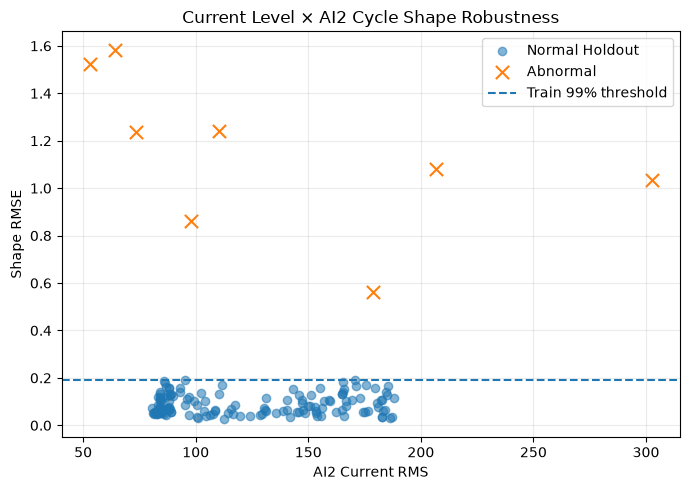

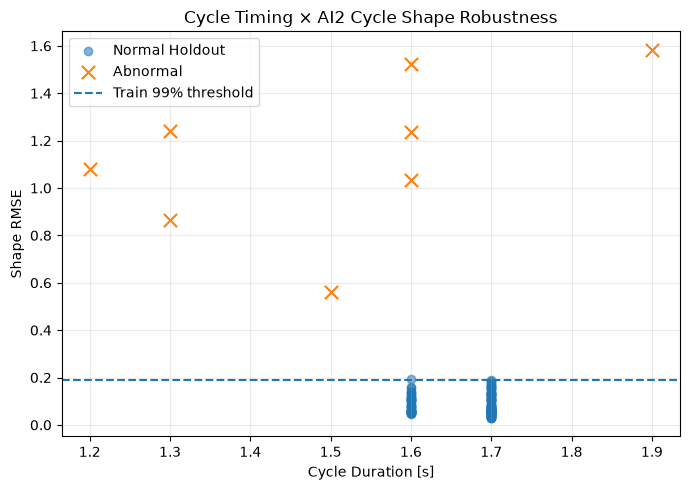


Saved to: c:\Users\astra\Desktop\K_eng\KAMP\05_EDA\05_Physics_Informed\03_1_Shape_Robustness_results


In [1]:
# Normal Train에서 AI2 Cycle Shape threshold와 Current 구간을 고정한다.
# Normal Holdout에서 Shape RMSE가 Current·Timing·Low-RMS regime에 민감한지 검증한다.
# 운전조건이 달라도 Shape 지표가 안정적이면 독립적인 Cycle-structure feature로 유지한다.
# threshold는 Train에서만 정하고 Holdout은 순수 검증에만 사용한다.

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

SHAPE_Q = .99
LOW_RMS_START, LOW_RMS_END = 3600, 4300


# ------------------------------------------------------------
# 1. 경로 / 결과 불러오기
# ------------------------------------------------------------
def find_root():
    starts = [Path.cwd()]
    try: starts.append(Path(__file__).resolve().parent)
    except NameError: pass
    for start in starts:
        for p in [start, *start.parents]:
            if (p / "KAMP/05_EDA/05_Physics_Informed/03_Current_Shape_results").exists(): return p
    raise FileNotFoundError("03_Current_Shape_results를 찾지 못했습니다.")

ROOT = find_root()
SHAPE_DIR = ROOT / "KAMP/05_EDA/05_Physics_Informed/03_Current_Shape_results"
PORD_DIR = ROOT / "KAMP/05_EDA/05_Physics_Informed/01_PORD_results"
OUT = ROOT / "KAMP/05_EDA/05_Physics_Informed/03_1_Shape_Robustness_results"
OUT.mkdir(parents=True, exist_ok=True)

train = pd.read_csv(SHAPE_DIR / "normal_train_current_shape.csv")
holdout = pd.read_csv(SHAPE_DIR / "normal_holdout_current_shape.csv")
abnormal = pd.read_csv(SHAPE_DIR / "abnormal_current_shape.csv")
pord_holdout = pd.read_csv(PORD_DIR / "normal_holdout_pord.csv")


# ------------------------------------------------------------
# 2. Train 기준 고정
# ------------------------------------------------------------
RMSE_TH = train.Shape_RMSE.quantile(SHAPE_Q)
CORR_TH = train.Template_Corr.quantile(1 - SHAPE_Q)
CUR_Q1, CUR_Q2 = train.AI2_Current_rms.quantile([1/3, 2/3])

def add_groups(df):
    out = df.copy()
    out["Shape_Break_Fixed"] = out.Shape_RMSE > RMSE_TH
    out["Current_Group"] = pd.cut(
        out.AI2_Current_rms, [-np.inf, CUR_Q1, CUR_Q2, np.inf],
        labels=["Low", "Mid", "High"]
    )
    out["Timing_Group"] = out.duration_sec.round(1).astype(str) + " s"
    return out

train, holdout, abnormal = map(add_groups, [train, holdout, abnormal])


# ------------------------------------------------------------
# 3. Low-RMS regime 정보 결합
# ------------------------------------------------------------
regime = pord_holdout[
    ["segment_id", "cycle_id", "start_elapsed_sec"]
].copy()

regime["Low_RMS_Regime"] = regime.start_elapsed_sec.between(
    LOW_RMS_START, LOW_RMS_END
)

holdout = holdout.merge(
    regime[["segment_id", "cycle_id", "Low_RMS_Regime"]],
    on=["segment_id", "cycle_id"], how="left"
)

holdout["Low_RMS_Regime"] = holdout.Low_RMS_Regime.fillna(False).astype(bool)


# ------------------------------------------------------------
# 4. 전체 Robustness
# ------------------------------------------------------------
rho_i, p_i = spearmanr(holdout.AI2_Current_rms, holdout.Shape_RMSE)
rho_t, p_t = spearmanr(holdout.duration_sec, holdout.Shape_RMSE)

print("=== Fixed Shape Reference ===")
print(f"Train Shape RMSE 99% threshold : {RMSE_TH:.4f}")
print(f"Train Corr 1% reference        : {CORR_TH:.4f}")
print(f"Holdout Shape FPR              : {holdout.Shape_Break_Fixed.mean():.4f}")

print("\n=== Shape RMSE Dependency ===")
print(f"Current RMS ↔ Shape RMSE : rho={rho_i:.4f}, p={p_i:.4g}")
print(f"Duration    ↔ Shape RMSE : rho={rho_t:.4f}, p={p_t:.4g}")


# ------------------------------------------------------------
# 5. Current 수준별 안정성
# ------------------------------------------------------------
print("\n=== Current Group Robustness ===")
current_summary = holdout.groupby("Current_Group", observed=True).agg(
    n=("Shape_RMSE", "size"),
    median=("Shape_RMSE", "median"),
    q95=("Shape_RMSE", lambda x: x.quantile(.95)),
    q99=("Shape_RMSE", lambda x: x.quantile(.99)),
    FPR=("Shape_Break_Fixed", "mean")
).round(4)

print(current_summary.to_string())


# ------------------------------------------------------------
# 6. Timing별 안정성
# ------------------------------------------------------------
print("\n=== Timing Group Robustness ===")
timing_summary = holdout.groupby("Timing_Group").agg(
    n=("Shape_RMSE", "size"),
    median=("Shape_RMSE", "median"),
    q95=("Shape_RMSE", lambda x: x.quantile(.95)),
    q99=("Shape_RMSE", lambda x: x.quantile(.99)),
    FPR=("Shape_Break_Fixed", "mean")
).round(4)

print(timing_summary.to_string())


# ------------------------------------------------------------
# 7. Low-RMS regime 안정성
# ------------------------------------------------------------
print("\n=== Low-RMS Regime Robustness ===")
regime_summary = holdout.groupby("Low_RMS_Regime").agg(
    n=("Shape_RMSE", "size"),
    median=("Shape_RMSE", "median"),
    q95=("Shape_RMSE", lambda x: x.quantile(.95)),
    FPR=("Shape_Break_Fixed", "mean")
).round(4)

regime_summary.index = ["Other", "Low-RMS"] if len(regime_summary) == 2 else regime_summary.index
print(regime_summary.to_string())


# ------------------------------------------------------------
# 8. Abnormal 재평가
# ------------------------------------------------------------
print("\n=== Abnormal with Train-fixed Threshold ===")
cols = [
    "segment_id", "cycle_id", "duration_sec", "AI2_Current_rms",
    "Shape_RMSE", "Template_Corr", "Shape_Break_Fixed"
]
print(abnormal[cols].round(4).to_string(index=False))

print("\n=== Final Shape Result ===")
print(f"Holdout FPR    : {holdout.Shape_Break_Fixed.mean():.4f}")
print(f"Abnormal break : {abnormal.Shape_Break_Fixed.sum()} / {len(abnormal)}")


# ------------------------------------------------------------
# 9. Current RMS × Shape RMSE
# ------------------------------------------------------------
plt.figure(figsize=(7, 5))
plt.scatter(holdout.AI2_Current_rms, holdout.Shape_RMSE, alpha=.55, label="Normal Holdout")
plt.scatter(abnormal.AI2_Current_rms, abnormal.Shape_RMSE, marker="x", s=90, label="Abnormal")
plt.axhline(RMSE_TH, linestyle="--", label=f"Train {SHAPE_Q:.0%} threshold")
plt.xlabel("AI2 Current RMS"); plt.ylabel("Shape RMSE")
plt.title("Current Level × AI2 Cycle Shape Robustness")
plt.legend(); plt.grid(alpha=.25); plt.tight_layout()
plt.savefig(OUT / "current_vs_shape_rmse.png", dpi=150)
plt.show()


# ------------------------------------------------------------
# 10. Timing × Shape RMSE
# ------------------------------------------------------------
plt.figure(figsize=(7, 5))
plt.scatter(holdout.duration_sec, holdout.Shape_RMSE, alpha=.55, label="Normal Holdout")
plt.scatter(abnormal.duration_sec, abnormal.Shape_RMSE, marker="x", s=90, label="Abnormal")
plt.axhline(RMSE_TH, linestyle="--", label=f"Train {SHAPE_Q:.0%} threshold")
plt.xlabel("Cycle Duration [s]"); plt.ylabel("Shape RMSE")
plt.title("Cycle Timing × AI2 Cycle Shape Robustness")
plt.legend(); plt.grid(alpha=.25); plt.tight_layout()
plt.savefig(OUT / "timing_vs_shape_rmse.png", dpi=150)
plt.show()


# ------------------------------------------------------------
# 11. 저장
# ------------------------------------------------------------
holdout.to_csv(OUT / "normal_holdout_shape_robustness.csv", index=False)
abnormal.to_csv(OUT / "abnormal_shape_fixed_threshold.csv", index=False)
current_summary.to_csv(OUT / "current_group_summary.csv")
timing_summary.to_csv(OUT / "timing_group_summary.csv")
regime_summary.to_csv(OUT / "regime_summary.csv")

print(f"\nSaved to: {OUT}")

=== CNVG Normal Reference ===
AI2 Train Median           : 105.4047
AI2 Current Support        : 81.3628 ~ 190.9114
AI0 Vibration Median       : 0.068384
AI1 Vibration Median       : 0.085797
Train CNVG 99% threshold   : 0.8549
Normal Holdout FPR         : 0.0207

=== CNVG Dependency / Redundancy ===
Current RMS ↔ CNVG : rho=-0.3843, p=1.829e-06
PORD ↔ CNVG        : rho=0.3522, p=1.394e-05

=== Channel Gain Dependency ===
AI0 Current ↔ Gain : rho=-0.1525, p=0.06703
AI1 Current ↔ Gain : rho=0.8168, p=5.585e-36

=== Abnormal CNVG ===
segment_id  cycle_id  duration_sec  AI2_Current_rms  Current_IN  AI0_Gain  AI1_Gain  AI0_GainDev  AI1_GainDev   CNVG  CNVG_break    PORD  PORD_break
     A0001         1           1.3          97.8139        True    8.4945    3.6060       2.3282       1.2696 2.3282        True 31.1487        True
     A0001         2           1.3         110.1892        True    6.7652    3.3897       2.1005       1.2077 2.1005        True 27.2435        True
     A0006     

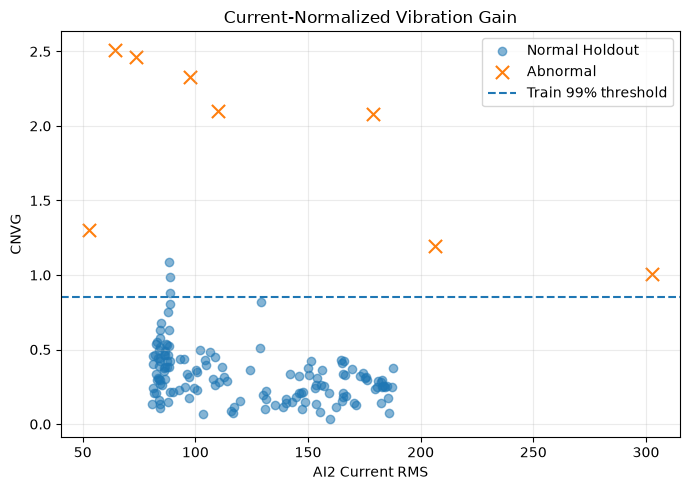

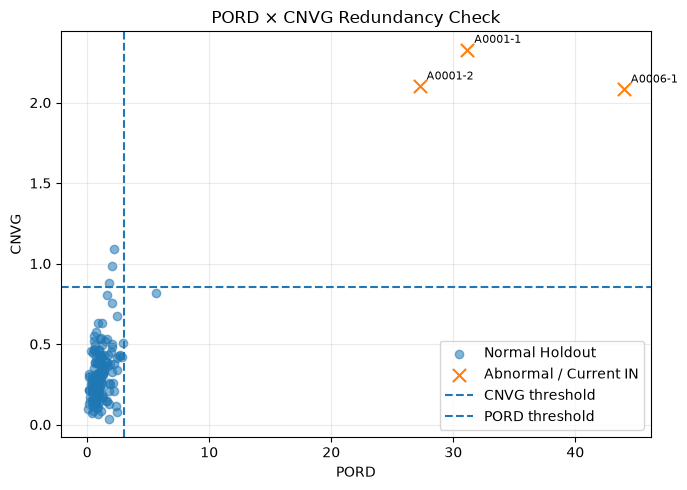


Saved to: c:\Users\astra\Desktop\K_eng\KAMP\05_EDA\05_Physics_Informed\04_CNVG_results


In [2]:
# CNVG: AI2 Current 수준 대비 AI0/AI1 진동응답의 상대적 크기를 계산한다.
# Normal Train 중앙값으로 무차원화하고 정상 Gain에서 벗어난 정도를 로그거리로 표현한다.
# Holdout FPR과 Abnormal 분리력을 확인하고 기존 PORD와 중복되는지 직접 비교한다.
# AI2는 실제 load가 아니므로 Load Gain이 아니라 Current-Normalized Vibration Gain으로 해석한다.

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

Q_LO, Q_HI, TH_Q = .005, .995, .99
EPS = 1e-12


# ------------------------------------------------------------
# 1. 경로 / PORD 결과
# ------------------------------------------------------------
def find_root():
    starts = [Path.cwd()]
    try: starts.append(Path(__file__).resolve().parent)
    except NameError: pass
    for start in starts:
        for p in [start, *start.parents]:
            if (p / "KAMP/05_EDA/05_Physics_Informed/01_PORD_results").exists(): return p
    raise FileNotFoundError("01_PORD_results를 찾지 못했습니다.")

ROOT = find_root()
PORD_DIR = ROOT / "KAMP/05_EDA/05_Physics_Informed/01_PORD_results"
OUT = ROOT / "KAMP/05_EDA/05_Physics_Informed/04_CNVG_results"
OUT.mkdir(parents=True, exist_ok=True)

train = pd.read_csv(PORD_DIR / "normal_train_pord.csv")
holdout = pd.read_csv(PORD_DIR / "normal_holdout_pord.csv")
abnormal = pd.read_csv(PORD_DIR / "abnormal_fullcycle_pord.csv")


# ------------------------------------------------------------
# 2. Normal Train 기준 Gain 정의
# ------------------------------------------------------------
I_MED = train.AI2_Current_rms.median()
I_LO, I_HI = train.AI2_Current_rms.quantile([Q_LO, Q_HI])
V_MED = {ch: train[f"{ch}_Vibration_rms"].median() for ch in ["AI0", "AI1"]}

def add_gain(df):
    out = df.copy()
    out["Current_IN"] = out.AI2_Current_rms.between(I_LO, I_HI)

    for ch in ["AI0", "AI1"]:
        out[f"{ch}_Gain"] = (
            out[f"{ch}_Vibration_rms"] / V_MED[ch]
        ) / (
            out.AI2_Current_rms / I_MED
        )

    return out

train, holdout, abnormal = map(add_gain, [train, holdout, abnormal])

GAIN_MED = {ch: train[f"{ch}_Gain"].median() for ch in ["AI0", "AI1"]}

def add_gain_deviation(df):
    out = df.copy()

    for ch in ["AI0", "AI1"]:
        out[f"{ch}_GainDev"] = np.abs(
            np.log((out[f"{ch}_Gain"] + EPS) / (GAIN_MED[ch] + EPS))
        )

    out["CNVG"] = np.maximum(out.AI0_GainDev, out.AI1_GainDev)
    return out

train, holdout, abnormal = map(add_gain_deviation, [train, holdout, abnormal])

CNVG_TH = train.CNVG.quantile(TH_Q)

for df in [train, holdout, abnormal]:
    df["CNVG_break"] = df.CNVG > CNVG_TH


# ------------------------------------------------------------
# 3. Normal Holdout 검증
# ------------------------------------------------------------
rho_c, p_c = spearmanr(holdout.AI2_Current_rms, holdout.CNVG)
rho_p, p_p = spearmanr(holdout.PORD, holdout.CNVG, nan_policy="omit")

print("=== CNVG Normal Reference ===")
print(f"AI2 Train Median           : {I_MED:.4f}")
print(f"AI2 Current Support        : {I_LO:.4f} ~ {I_HI:.4f}")
print(f"AI0 Vibration Median       : {V_MED['AI0']:.6f}")
print(f"AI1 Vibration Median       : {V_MED['AI1']:.6f}")
print(f"Train CNVG 99% threshold   : {CNVG_TH:.4f}")
print(f"Normal Holdout FPR         : {holdout.CNVG_break.mean():.4f}")

print("\n=== CNVG Dependency / Redundancy ===")
print(f"Current RMS ↔ CNVG : rho={rho_c:.4f}, p={p_c:.4g}")
print(f"PORD ↔ CNVG        : rho={rho_p:.4f}, p={p_p:.4g}")


# ------------------------------------------------------------
# 4. 채널별 Current 의존성 확인
# ------------------------------------------------------------
print("\n=== Channel Gain Dependency ===")
for ch in ["AI0", "AI1"]:
    rho, p = spearmanr(holdout.AI2_Current_rms, holdout[f"{ch}_Gain"])
    print(f"{ch} Current ↔ Gain : rho={rho:.4f}, p={p:.4g}")


# ------------------------------------------------------------
# 5. Abnormal 평가
# ------------------------------------------------------------
ab_in = abnormal[abnormal.Current_IN].copy()

cols = [
    "segment_id", "cycle_id", "duration_sec", "AI2_Current_rms",
    "Current_IN", "AI0_Gain", "AI1_Gain", "AI0_GainDev",
    "AI1_GainDev", "CNVG", "CNVG_break", "PORD", "PORD_break"
]

print("\n=== Abnormal CNVG ===")
print(abnormal[cols].round(4).to_string(index=False))

print("\n=== Current In-range Abnormal ===")
print(f"Current IN   : {len(ab_in)} / {len(abnormal)}")
print(f"CNVG break   : {ab_in.CNVG_break.sum()} / {len(ab_in)}")
print(f"PORD break   : {ab_in.PORD_break.sum()} / {len(ab_in)}")

if len(ab_in):
    only_gain = (ab_in.CNVG_break & ~ab_in.PORD_break).sum()
    only_pord = (~ab_in.CNVG_break & ab_in.PORD_break).sum()
    both = (ab_in.CNVG_break & ab_in.PORD_break).sum()

    print(f"Both break   : {both}")
    print(f"CNVG only    : {only_gain}")
    print(f"PORD only    : {only_pord}")


# ------------------------------------------------------------
# 6. Normal Current 그룹별 CNVG 안정성
# ------------------------------------------------------------
q1, q2 = train.AI2_Current_rms.quantile([1/3, 2/3])

holdout["Current_Group"] = pd.cut(
    holdout.AI2_Current_rms,
    [-np.inf, q1, q2, np.inf],
    labels=["Low", "Mid", "High"]
)

summary = holdout.groupby("Current_Group", observed=True).agg(
    n=("CNVG", "size"),
    median=("CNVG", "median"),
    q95=("CNVG", lambda x: x.quantile(.95)),
    q99=("CNVG", lambda x: x.quantile(.99)),
    FPR=("CNVG_break", "mean")
).round(4)

print("\n=== Current Group Robustness ===")
print(summary.to_string())


# ------------------------------------------------------------
# 7. Current RMS × CNVG
# ------------------------------------------------------------
plt.figure(figsize=(7, 5))
plt.scatter(holdout.AI2_Current_rms, holdout.CNVG, alpha=.55, label="Normal Holdout")
plt.scatter(abnormal.AI2_Current_rms, abnormal.CNVG, marker="x", s=90, label="Abnormal")
plt.axhline(CNVG_TH, linestyle="--", label=f"Train {TH_Q:.0%} threshold")
plt.xlabel("AI2 Current RMS"); plt.ylabel("CNVG")
plt.title("Current-Normalized Vibration Gain")
plt.legend(); plt.grid(alpha=.25); plt.tight_layout()
plt.savefig(OUT / "current_vs_cnvg.png", dpi=150)
plt.show()


# ------------------------------------------------------------
# 8. PORD × CNVG 중복성
# ------------------------------------------------------------
plt.figure(figsize=(7, 5))
plt.scatter(holdout.PORD, holdout.CNVG, alpha=.55, label="Normal Holdout")
plt.scatter(ab_in.PORD, ab_in.CNVG, marker="x", s=90, label="Abnormal / Current IN")

for _, r in ab_in.iterrows():
    plt.annotate(
        f"{r.segment_id}-{int(r.cycle_id)}",
        (r.PORD, r.CNVG), xytext=(5, 5),
        textcoords="offset points", fontsize=8
    )

plt.axhline(CNVG_TH, linestyle="--", label="CNVG threshold")
plt.axvline(3.0, linestyle="--", label="PORD threshold")
plt.xlabel("PORD"); plt.ylabel("CNVG")
plt.title("PORD × CNVG Redundancy Check")
plt.legend(); plt.grid(alpha=.25); plt.tight_layout()
plt.savefig(OUT / "pord_vs_cnvg.png", dpi=150)
plt.show()


# ------------------------------------------------------------
# 9. 저장
# ------------------------------------------------------------
train.to_csv(OUT / "normal_train_cnvg.csv", index=False)
holdout.to_csv(OUT / "normal_holdout_cnvg.csv", index=False)
abnormal.to_csv(OUT / "abnormal_cnvg.csv", index=False)
summary.to_csv(OUT / "current_group_cnvg_summary.csv")

print(f"\nSaved to: {OUT}")

=== Normal Phase Activity Reference ===
Phase A median : 0.3119
Phase B median : 0.4636
Phase C median : 0.2270
D_phase 99% threshold : 0.1186
Normal Holdout FPR     : 0.0069

=== Dependency / Redundancy ===
D_phase ↔ Shape RMSE  : rho=0.5468, p=1.116e-12
D_phase ↔ Current RMS : rho=-0.0339, p=0.6854
D_phase ↔ Duration    : rho=-0.0075, p=0.9283

=== Abnormal Phase-domain Current Activity ===
segment_id  cycle_id  duration_sec  AI2_Current_rms  Phase_A  Phase_B  Phase_C  D_phase  Phase_Break  Shape_RMSE
     A0001         1           1.3          97.8139   0.5425   0.3318   0.1257   0.4635         True      0.8628
     A0001         2           1.3         110.1892   0.3048   0.4174   0.2778   0.1041        False      1.2401
     A0006         1           1.5         178.8959   0.4556   0.3549   0.1895   0.2899         True      0.5603
     A0011         1           1.6          52.9194   0.4402   0.2092   0.3506   0.5062         True      1.5245
     A0011         2           1.6     

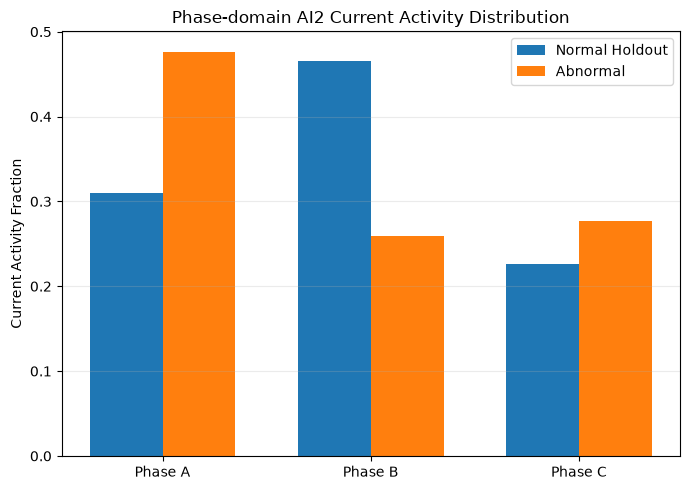

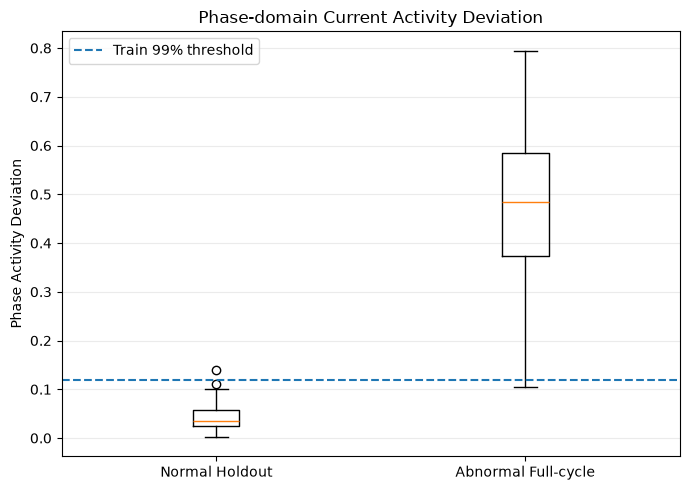

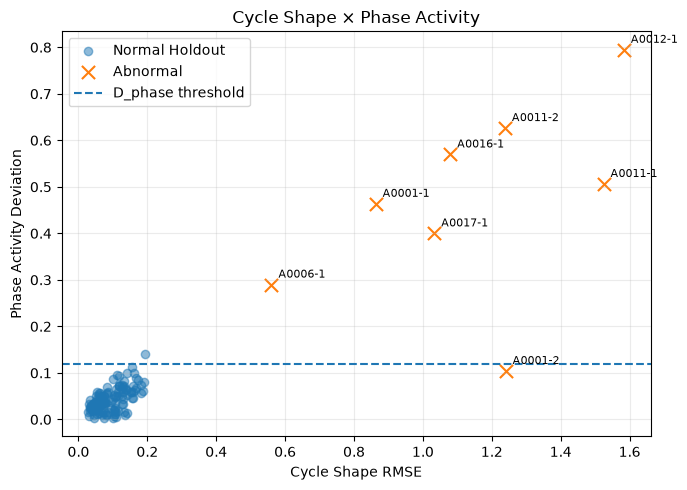


Saved to: c:\Users\astra\Desktop\K_eng\KAMP\05_EDA\05_Physics_Informed\05_Phase_Current_Activity_results


In [3]:
# AI2 Current cycle의 상대위상 A/B/C별 activity 분포를 계산한다.
# 각 cycle을 phase-normalize + z-normalize한 뒤 구간별 제곱합 비율을 구한다.
# Normal Train의 phase 분포와의 차이를 D_phase로 정의하고 Holdout/Abnormal에서 검증한다.
# A/B/C는 실제 FA/BS/HR 공정단계가 아니라 단순 상대 Cycle Phase다.

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.stats import spearmanr

MIN_SEG_ROWS, MIN_PEAK_DIST, N_PHASE = 30, 12, 30
TH_Q = .99


# ------------------------------------------------------------
# 1. 경로 / 기존 split
# ------------------------------------------------------------
def find_root():
    starts = [Path.cwd()]
    try: starts.append(Path(__file__).resolve().parent)
    except NameError: pass

    for start in starts:
        for p in [start, *start.parents]:
            if (p / "data/processed/preprocessed_data.csv").exists(): return p

    raise FileNotFoundError("프로젝트 root를 찾지 못했습니다.")

ROOT = find_root()
DATA_PATH = ROOT / "data/processed/preprocessed_data.csv"
PORD_DIR = ROOT / "KAMP/05_EDA/05_Physics_Informed/01_PORD_results"
SHAPE_DIR = ROOT / "KAMP/05_EDA/05_Physics_Informed/03_Current_Shape_results"
OUT = ROOT / "KAMP/05_EDA/05_Physics_Informed/05_Phase_Current_Activity_results"
OUT.mkdir(parents=True, exist_ok=True)

data = pd.read_csv(DATA_PATH)
train_seg = set(pd.read_csv(PORD_DIR / "normal_train_pord.csv").segment_id.unique())
holdout_seg = set(pd.read_csv(PORD_DIR / "normal_holdout_pord.csv").segment_id.unique())


# ------------------------------------------------------------
# 2. Cycle 추출 / 상대위상 정규화
# ------------------------------------------------------------
def phase_shape(x):
    x = np.asarray(x, float)
    old, new = np.linspace(0, 1, len(x)), np.linspace(0, 1, N_PHASE)
    y = np.interp(new, old, x)
    sd = y.std(ddof=1)
    if sd == 0: return None
    return (y - y.mean()) / sd

def extract_cycles(df, source):
    rows, shapes = [], []

    for seg, g in df[df.source == source].groupby("segment_id", sort=False):
        g = g.sort_values("pos_in_seg").reset_index(drop=True)
        if len(g) < MIN_SEG_ROWS: continue

        cur = g.AI2_Current.to_numpy(float)
        sm = pd.Series(cur).rolling(3, center=True, min_periods=1).median().to_numpy()
        prom = max(np.std(sm, ddof=1) * .5, np.finfo(float).eps)
        peaks, _ = find_peaks(sm, distance=MIN_PEAK_DIST, prominence=prom)

        for cid, (s, e) in enumerate(zip(peaks[:-1], peaks[1:]), 1):
            if e - s < MIN_PEAK_DIST: continue

            c = g.iloc[s:e + 1]
            duration = c.elapsed_sec.iloc[-1] - c.elapsed_sec.iloc[0]
            shape = phase_shape(c.AI2_Current)

            if duration <= 0 or shape is None: continue

            rows.append({
                "source": source, "segment_id": seg, "cycle_id": cid,
                "duration_sec": float(duration),
                "AI2_Current_rms": float(np.sqrt(np.mean(c.AI2_Current.to_numpy(float) ** 2)))
            })
            shapes.append(shape)

    return pd.DataFrame(rows), np.vstack(shapes)

normal_meta, normal_shape = extract_cycles(data, "normal")
abnormal_meta, abnormal_shape = extract_cycles(data, "abnormal")

train_mask = normal_meta.segment_id.isin(train_seg).to_numpy()
holdout_mask = normal_meta.segment_id.isin(holdout_seg).to_numpy()

train_meta, train_shape = normal_meta[train_mask].copy(), normal_shape[train_mask]
holdout_meta, holdout_shape = normal_meta[holdout_mask].copy(), normal_shape[holdout_mask]


# ------------------------------------------------------------
# 3. Phase A/B/C Activity Fraction
# ------------------------------------------------------------
def phase_activity(shapes):
    e = shapes ** 2
    total = e.sum(axis=1) + 1e-12
    cuts = np.array_split(np.arange(N_PHASE), 3)

    return pd.DataFrame({
        "Phase_A": e[:, cuts[0]].sum(axis=1) / total,
        "Phase_B": e[:, cuts[1]].sum(axis=1) / total,
        "Phase_C": e[:, cuts[2]].sum(axis=1) / total
    })

train_act = phase_activity(train_shape)
holdout_act = phase_activity(holdout_shape)
abnormal_act = phase_activity(abnormal_shape)

train_meta = pd.concat([train_meta.reset_index(drop=True), train_act], axis=1)
holdout_meta = pd.concat([holdout_meta.reset_index(drop=True), holdout_act], axis=1)
abnormal_meta = pd.concat([abnormal_meta.reset_index(drop=True), abnormal_act], axis=1)


# ------------------------------------------------------------
# 4. Normal Train 기준 D_phase
# ------------------------------------------------------------
PHASE_REF = train_meta[["Phase_A", "Phase_B", "Phase_C"]].median()

def add_phase_deviation(df):
    out = df.copy()
    out["D_phase"] = (
        (out.Phase_A - PHASE_REF.Phase_A).abs()
        + (out.Phase_B - PHASE_REF.Phase_B).abs()
        + (out.Phase_C - PHASE_REF.Phase_C).abs()
    )
    return out

train_meta, holdout_meta, abnormal_meta = map(
    add_phase_deviation, [train_meta, holdout_meta, abnormal_meta]
)

D_TH = train_meta.D_phase.quantile(TH_Q)

for df in [train_meta, holdout_meta, abnormal_meta]:
    df["Phase_Break"] = df.D_phase > D_TH


# ------------------------------------------------------------
# 5. 기존 Shape RMSE와 결합
# ------------------------------------------------------------
hold_shape = pd.read_csv(SHAPE_DIR / "normal_holdout_current_shape.csv")
ab_shape = pd.read_csv(SHAPE_DIR / "abnormal_current_shape.csv")

holdout_meta = holdout_meta.merge(
    hold_shape[["segment_id", "cycle_id", "Shape_RMSE"]],
    on=["segment_id", "cycle_id"], how="left"
)

abnormal_meta = abnormal_meta.merge(
    ab_shape[["segment_id", "cycle_id", "Shape_RMSE"]],
    on=["segment_id", "cycle_id"], how="left"
)


# ------------------------------------------------------------
# 6. 결과 요약
# ------------------------------------------------------------
rho_s, p_s = spearmanr(holdout_meta.D_phase, holdout_meta.Shape_RMSE)
rho_i, p_i = spearmanr(holdout_meta.D_phase, holdout_meta.AI2_Current_rms)
rho_t, p_t = spearmanr(holdout_meta.D_phase, holdout_meta.duration_sec)

print("=== Normal Phase Activity Reference ===")
print(f"Phase A median : {PHASE_REF.Phase_A:.4f}")
print(f"Phase B median : {PHASE_REF.Phase_B:.4f}")
print(f"Phase C median : {PHASE_REF.Phase_C:.4f}")
print(f"D_phase 99% threshold : {D_TH:.4f}")
print(f"Normal Holdout FPR     : {holdout_meta.Phase_Break.mean():.4f}")

print("\n=== Dependency / Redundancy ===")
print(f"D_phase ↔ Shape RMSE  : rho={rho_s:.4f}, p={p_s:.4g}")
print(f"D_phase ↔ Current RMS : rho={rho_i:.4f}, p={p_i:.4g}")
print(f"D_phase ↔ Duration    : rho={rho_t:.4f}, p={p_t:.4g}")


# ------------------------------------------------------------
# 7. Abnormal 결과
# ------------------------------------------------------------
cols = [
    "segment_id", "cycle_id", "duration_sec", "AI2_Current_rms",
    "Phase_A", "Phase_B", "Phase_C", "D_phase",
    "Phase_Break", "Shape_RMSE"
]

print("\n=== Abnormal Phase-domain Current Activity ===")
print(abnormal_meta[cols].round(4).to_string(index=False))

print("\n=== Abnormal Summary ===")
print(f"Full cycles  : {len(abnormal_meta)}")
print(f"Phase break  : {abnormal_meta.Phase_Break.sum()} / {len(abnormal_meta)}")


# ------------------------------------------------------------
# 8. Phase별 Normal vs Abnormal 분포
# ------------------------------------------------------------
labels = ["Phase A", "Phase B", "Phase C"]
normal_med = [holdout_meta.Phase_A.median(), holdout_meta.Phase_B.median(), holdout_meta.Phase_C.median()]
abnormal_med = [abnormal_meta.Phase_A.median(), abnormal_meta.Phase_B.median(), abnormal_meta.Phase_C.median()]

x = np.arange(3)
w = .35

plt.figure(figsize=(7, 5))
plt.bar(x - w/2, normal_med, w, label="Normal Holdout")
plt.bar(x + w/2, abnormal_med, w, label="Abnormal")
plt.xticks(x, labels)
plt.ylabel("Current Activity Fraction")
plt.title("Phase-domain AI2 Current Activity Distribution")
plt.legend(); plt.grid(axis="y", alpha=.25); plt.tight_layout()
plt.savefig(OUT / "phase_activity_distribution.png", dpi=150)
plt.show()


# ------------------------------------------------------------
# 9. D_phase 분포
# ------------------------------------------------------------
plt.figure(figsize=(7, 5))
plt.boxplot(
    [holdout_meta.D_phase, abnormal_meta.D_phase],
    tick_labels=["Normal Holdout", "Abnormal Full-cycle"]
)
plt.axhline(D_TH, linestyle="--", label=f"Train {TH_Q:.0%} threshold")
plt.ylabel("Phase Activity Deviation")
plt.title("Phase-domain Current Activity Deviation")
plt.legend(); plt.grid(axis="y", alpha=.25); plt.tight_layout()
plt.savefig(OUT / "phase_deviation_normal_vs_abnormal.png", dpi=150)
plt.show()


# ------------------------------------------------------------
# 10. Shape RMSE × D_phase 중복성
# ------------------------------------------------------------
plt.figure(figsize=(7, 5))
plt.scatter(holdout_meta.Shape_RMSE, holdout_meta.D_phase, alpha=.5, label="Normal Holdout")
plt.scatter(abnormal_meta.Shape_RMSE, abnormal_meta.D_phase, marker="x", s=90, label="Abnormal")

for _, r in abnormal_meta.iterrows():
    plt.annotate(
        f"{r.segment_id}-{int(r.cycle_id)}",
        (r.Shape_RMSE, r.D_phase),
        xytext=(5, 5), textcoords="offset points", fontsize=8
    )

plt.axhline(D_TH, linestyle="--", label="D_phase threshold")
plt.xlabel("Cycle Shape RMSE")
plt.ylabel("Phase Activity Deviation")
plt.title("Cycle Shape × Phase Activity")
plt.legend(); plt.grid(alpha=.25); plt.tight_layout()
plt.savefig(OUT / "shape_vs_phase_deviation.png", dpi=150)
plt.show()


# ------------------------------------------------------------
# 11. 저장
# ------------------------------------------------------------
train_meta.to_csv(OUT / "normal_train_phase_activity.csv", index=False)
holdout_meta.to_csv(OUT / "normal_holdout_phase_activity.csv", index=False)
abnormal_meta.to_csv(OUT / "abnormal_phase_activity.csv", index=False)

print(f"\nSaved to: {OUT}")

=== Cycle-Harmonic Ensemble Coherence ===
AI0: Train=0.0000 | Holdout=0.0220 | Abnormal=0.0303
AI1: Train=0.0046 | Holdout=0.0036 | Abnormal=0.0376

=== OCVT Normal Reference ===
AI0: |H| median=0.000069, phase=-19.73°, MagDev99=2.0877, PhaseDev99=177.58°
AI1: |H| median=0.000069, phase=-149.58°, MagDev99=1.9482, PhaseDev99=179.10°

Normal Holdout OCVT FPR : 0.0276

=== Normal Holdout Robustness ===
AI2_Current_rms  ↔ OCVT : rho=0.0735, p=0.3794
duration_sec     ↔ OCVT : rho=-0.0889, p=0.2878

=== OCVT Redundancy ===
OCVT ↔ Shape RMSE : rho=0.1208, p=0.1477
OCVT ↔ PORD       : rho=-0.0467, p=0.5772

=== Abnormal OCVT ===
segment_id  cycle_id  duration_sec  AI2_Current_rms  AI0_H_mag  AI0_H_phase  AI0_OCVT_score  AI1_H_mag  AI1_H_phase  AI1_OCVT_score  OCVT_score  OCVT_break  Shape_RMSE    PORD
     A0001         1           1.3          97.8139     0.0059       1.4794          2.1294     0.0031      -0.3567          1.9455      2.1294        True      0.8628 31.1487
     A0001         

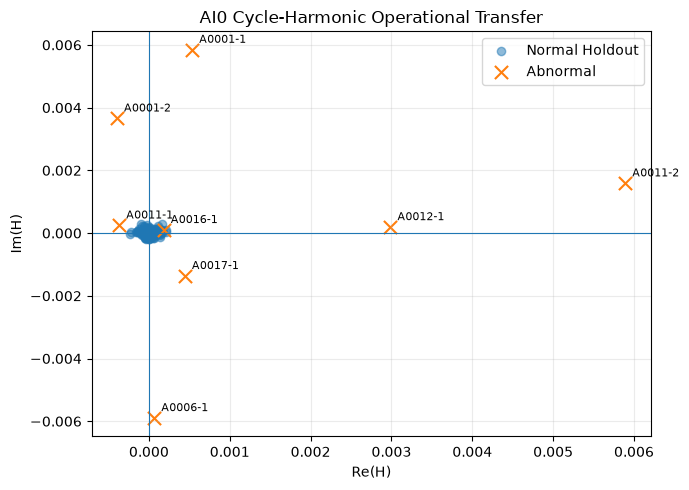

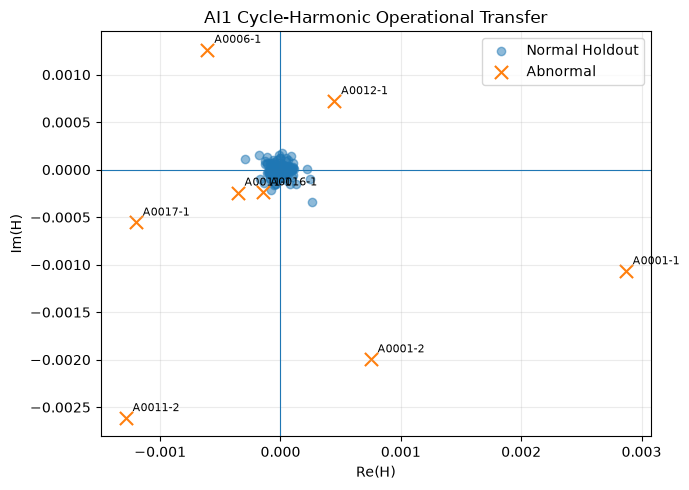

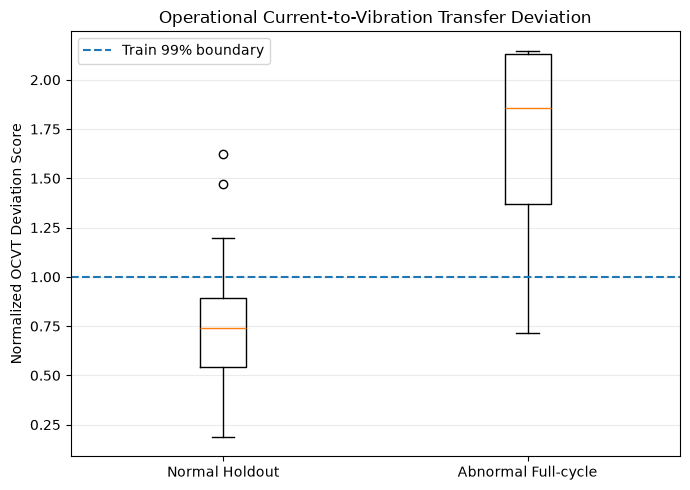


Saved to: c:\Users\astra\Desktop\K_eng\KAMP\05_EDA\05_Physics_Informed\06_OCVT_results


In [4]:
# OCVT: AI2 Current와 AI0/AI1 Vibration의 Cycle fundamental 동적 관계를 검증한다.
# 상대위상으로 정렬한 각 cycle에서 1차 complex harmonic을 추출해 magnitude/phase transfer를 계산한다.
# Normal Train으로 transfer 기준을 고정하고 Holdout/Abnormal 및 ensemble coherence를 평가한다.
# Force→Vibration FRF가 아니라 Cycle-Harmonic Operational Current-to-Vibration Transfer다.

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.stats import spearmanr

MIN_SEG_ROWS, MIN_PEAK_DIST, N_PHASE, TH_Q = 30, 12, 32, .99
EPS = 1e-12


# ------------------------------------------------------------
# 1. 경로 / 기존 split
# ------------------------------------------------------------
def find_root():
    starts = [Path.cwd()]
    try: starts.append(Path(__file__).resolve().parent)
    except NameError: pass
    for start in starts:
        for p in [start, *start.parents]:
            if (p / "data/processed/preprocessed_data.csv").exists(): return p
    raise FileNotFoundError("프로젝트 root를 찾지 못했습니다.")

ROOT = find_root()
DATA_PATH = ROOT / "data/processed/preprocessed_data.csv"
PORD_DIR = ROOT / "KAMP/05_EDA/05_Physics_Informed/01_PORD_results"
SHAPE_DIR = ROOT / "KAMP/05_EDA/05_Physics_Informed/03_Current_Shape_results"
OUT = ROOT / "KAMP/05_EDA/05_Physics_Informed/06_OCVT_results"
OUT.mkdir(parents=True, exist_ok=True)

data = pd.read_csv(DATA_PATH)
train_seg = set(pd.read_csv(PORD_DIR / "normal_train_pord.csv").segment_id.unique())
holdout_seg = set(pd.read_csv(PORD_DIR / "normal_holdout_pord.csv").segment_id.unique())


# ------------------------------------------------------------
# 2. Cycle 추출 / 상대위상 변환
# ------------------------------------------------------------
def phase_signal(x):
    x = np.asarray(x, float)
    old, new = np.linspace(0, 1, len(x)), np.linspace(0, 1, N_PHASE)
    return np.interp(new, old, x)

def extract_cycles(df, source):
    meta, sigs = [], []

    for seg, g in df[df.source == source].groupby("segment_id", sort=False):
        g = g.sort_values("pos_in_seg").reset_index(drop=True)
        if len(g) < MIN_SEG_ROWS: continue

        cur = g.AI2_Current.to_numpy(float)
        sm = pd.Series(cur).rolling(3, center=True, min_periods=1).median().to_numpy()
        prom = max(np.std(sm, ddof=1) * .5, np.finfo(float).eps)
        peaks, _ = find_peaks(sm, distance=MIN_PEAK_DIST, prominence=prom)

        for cid, (s, e) in enumerate(zip(peaks[:-1], peaks[1:]), 1):
            if e - s < MIN_PEAK_DIST: continue
            c = g.iloc[s:e + 1]
            duration = c.elapsed_sec.iloc[-1] - c.elapsed_sec.iloc[0]
            if duration <= 0: continue

            meta.append({
                "source": source, "segment_id": seg, "cycle_id": cid,
                "duration_sec": float(duration),
                "AI2_Current_rms": float(np.sqrt(np.mean(c.AI2_Current.to_numpy(float) ** 2)))
            })

            sigs.append(np.vstack([
                phase_signal(c.AI0_Vibration),
                phase_signal(c.AI1_Vibration),
                phase_signal(c.AI2_Current)
            ]))

    return pd.DataFrame(meta), np.stack(sigs)

normal_meta, normal_sig = extract_cycles(data, "normal")
abnormal_meta, abnormal_sig = extract_cycles(data, "abnormal")

tr = normal_meta.segment_id.isin(train_seg).to_numpy()
ho = normal_meta.segment_id.isin(holdout_seg).to_numpy()

train_meta, train_sig = normal_meta[tr].copy(), normal_sig[tr]
holdout_meta, holdout_sig = normal_meta[ho].copy(), normal_sig[ho]


# ------------------------------------------------------------
# 3. Cycle fundamental complex harmonic
# ------------------------------------------------------------
def first_harmonic(signals):
    centered = signals - signals.mean(axis=2, keepdims=True)
    return np.fft.rfft(centered, axis=2)[:, :, 1]

train_h = first_harmonic(train_sig)
holdout_h = first_harmonic(holdout_sig)
abnormal_h = first_harmonic(abnormal_sig)


# ------------------------------------------------------------
# 4. Operational Transfer H = V1 / I1
# ------------------------------------------------------------
def transfer_features(meta, harmonics):
    out = meta.reset_index(drop=True).copy()
    I = harmonics[:, 2]

    for idx, ch in enumerate(["AI0", "AI1"]):
        H = harmonics[:, idx] / (I + EPS)
        out[f"{ch}_H_real"] = H.real
        out[f"{ch}_H_imag"] = H.imag
        out[f"{ch}_H_mag"] = np.abs(H)
        out[f"{ch}_H_phase"] = np.angle(H)

    return out

train = transfer_features(train_meta, train_h)
holdout = transfer_features(holdout_meta, holdout_h)
abnormal = transfer_features(abnormal_meta, abnormal_h)


# ------------------------------------------------------------
# 5. Normal Train magnitude / phase reference
# ------------------------------------------------------------
def wrap_angle(x): return np.angle(np.exp(1j * x))

REF = {}

for ch in ["AI0", "AI1"]:
    mag = train[f"{ch}_H_mag"].to_numpy()
    phase = train[f"{ch}_H_phase"].to_numpy()

    phase_ref = np.angle(np.mean(np.exp(1j * phase)))
    mag_ref = np.median(mag)

    train[f"{ch}_MagDev"] = np.abs(np.log((mag + EPS) / (mag_ref + EPS)))
    train[f"{ch}_PhaseDev"] = np.abs(wrap_angle(phase - phase_ref))

    REF[ch] = {
        "mag_ref": mag_ref,
        "phase_ref": phase_ref,
        "mag_th": train[f"{ch}_MagDev"].quantile(TH_Q),
        "phase_th": train[f"{ch}_PhaseDev"].quantile(TH_Q)
    }

def add_deviation(df):
    out = df.copy()

    for ch in ["AI0", "AI1"]:
        r = REF[ch]
        out[f"{ch}_MagDev"] = np.abs(np.log((out[f"{ch}_H_mag"] + EPS) / (r["mag_ref"] + EPS)))
        out[f"{ch}_PhaseDev"] = np.abs(wrap_angle(out[f"{ch}_H_phase"] - r["phase_ref"]))
        out[f"{ch}_OCVT_score"] = np.maximum(
            out[f"{ch}_MagDev"] / (r["mag_th"] + EPS),
            out[f"{ch}_PhaseDev"] / (r["phase_th"] + EPS)
        )
        out[f"{ch}_OCVT_break"] = out[f"{ch}_OCVT_score"] > 1

    out["OCVT_score"] = np.maximum(out.AI0_OCVT_score, out.AI1_OCVT_score)
    out["OCVT_break"] = out.OCVT_score > 1
    return out

train, holdout, abnormal = map(add_deviation, [train, holdout, abnormal])


# ------------------------------------------------------------
# 6. Ensemble cycle-harmonic coherence
# ------------------------------------------------------------
def ensemble_coherence(h):
    I = h[:, 2]
    result = {}

    for idx, ch in enumerate(["AI0", "AI1"]):
        V = h[:, idx]
        siv = np.mean(np.conj(I) * V)
        sii, svv = np.mean(np.abs(I) ** 2), np.mean(np.abs(V) ** 2)
        result[ch] = float(np.abs(siv) ** 2 / (sii * svv + EPS))

    return result

coh_train = ensemble_coherence(train_h)
coh_holdout = ensemble_coherence(holdout_h)
coh_abnormal = ensemble_coherence(abnormal_h)

print("=== Cycle-Harmonic Ensemble Coherence ===")
for ch in ["AI0", "AI1"]:
    print(f"{ch}: Train={coh_train[ch]:.4f} | Holdout={coh_holdout[ch]:.4f} | Abnormal={coh_abnormal[ch]:.4f}")


# ------------------------------------------------------------
# 7. Reference / Holdout 검증
# ------------------------------------------------------------
print("\n=== OCVT Normal Reference ===")
for ch in ["AI0", "AI1"]:
    r = REF[ch]
    print(f"{ch}: |H| median={r['mag_ref']:.6f}, phase={np.degrees(r['phase_ref']):.2f}°, "
          f"MagDev99={r['mag_th']:.4f}, PhaseDev99={np.degrees(r['phase_th']):.2f}°")

print(f"\nNormal Holdout OCVT FPR : {holdout.OCVT_break.mean():.4f}")


# ------------------------------------------------------------
# 8. Current / Timing dependency
# ------------------------------------------------------------
print("\n=== Normal Holdout Robustness ===")
for x in ["AI2_Current_rms", "duration_sec"]:
    rho, p = spearmanr(holdout[x], holdout.OCVT_score)
    print(f"{x:16s} ↔ OCVT : rho={rho:.4f}, p={p:.4g}")


# ------------------------------------------------------------
# 9. 기존 Shape / PORD와 중복성
# ------------------------------------------------------------
pord_h = pd.read_csv(PORD_DIR / "normal_holdout_pord.csv")
pord_a = pd.read_csv(PORD_DIR / "abnormal_fullcycle_pord.csv")
shape_h = pd.read_csv(SHAPE_DIR / "normal_holdout_current_shape.csv")
shape_a = pd.read_csv(SHAPE_DIR / "abnormal_current_shape.csv")

holdout = holdout.merge(pord_h[["segment_id", "cycle_id", "PORD"]], on=["segment_id", "cycle_id"], how="left")
holdout = holdout.merge(shape_h[["segment_id", "cycle_id", "Shape_RMSE"]], on=["segment_id", "cycle_id"], how="left")
abnormal = abnormal.merge(pord_a[["segment_id", "cycle_id", "PORD"]], on=["segment_id", "cycle_id"], how="left")
abnormal = abnormal.merge(shape_a[["segment_id", "cycle_id", "Shape_RMSE"]], on=["segment_id", "cycle_id"], how="left")

rho_s, p_s = spearmanr(holdout.OCVT_score, holdout.Shape_RMSE)
valid_p = holdout.dropna(subset=["PORD"])
rho_p, p_p = spearmanr(valid_p.OCVT_score, valid_p.PORD)

print("\n=== OCVT Redundancy ===")
print(f"OCVT ↔ Shape RMSE : rho={rho_s:.4f}, p={p_s:.4g}")
print(f"OCVT ↔ PORD       : rho={rho_p:.4f}, p={p_p:.4g}")


# ------------------------------------------------------------
# 10. Abnormal
# ------------------------------------------------------------
cols = [
    "segment_id", "cycle_id", "duration_sec", "AI2_Current_rms",
    "AI0_H_mag", "AI0_H_phase", "AI0_OCVT_score",
    "AI1_H_mag", "AI1_H_phase", "AI1_OCVT_score",
    "OCVT_score", "OCVT_break", "Shape_RMSE", "PORD"
]

print("\n=== Abnormal OCVT ===")
print(abnormal[cols].round(4).to_string(index=False))

print("\n=== Abnormal Summary ===")
print(f"Full cycles : {len(abnormal)}")
print(f"OCVT break  : {abnormal.OCVT_break.sum()} / {len(abnormal)}")


# ------------------------------------------------------------
# 11. Complex transfer plane
# ------------------------------------------------------------
def plot_complex(ch):
    plt.figure(figsize=(7, 5))
    plt.scatter(holdout[f"{ch}_H_real"], holdout[f"{ch}_H_imag"], alpha=.5, label="Normal Holdout")
    plt.scatter(abnormal[f"{ch}_H_real"], abnormal[f"{ch}_H_imag"], marker="x", s=90, label="Abnormal")

    for _, r in abnormal.iterrows():
        plt.annotate(f"{r.segment_id}-{int(r.cycle_id)}",
                     (r[f"{ch}_H_real"], r[f"{ch}_H_imag"]),
                     xytext=(5, 5), textcoords="offset points", fontsize=8)

    plt.axhline(0, linewidth=.8); plt.axvline(0, linewidth=.8)
    plt.xlabel("Re(H)"); plt.ylabel("Im(H)")
    plt.title(f"{ch} Cycle-Harmonic Operational Transfer")
    plt.legend(); plt.grid(alpha=.25); plt.tight_layout()
    plt.savefig(OUT / f"{ch}_complex_transfer.png", dpi=150)
    plt.show()

for ch in ["AI0", "AI1"]: plot_complex(ch)


# ------------------------------------------------------------
# 12. OCVT score
# ------------------------------------------------------------
plt.figure(figsize=(7, 5))
plt.boxplot([holdout.OCVT_score, abnormal.OCVT_score],
            tick_labels=["Normal Holdout", "Abnormal Full-cycle"])
plt.axhline(1, linestyle="--", label="Train 99% boundary")
plt.ylabel("Normalized OCVT Deviation Score")
plt.title("Operational Current-to-Vibration Transfer Deviation")
plt.legend(); plt.grid(axis="y", alpha=.25); plt.tight_layout()
plt.savefig(OUT / "ocvt_score_normal_vs_abnormal.png", dpi=150)
plt.show()


# ------------------------------------------------------------
# 13. 저장
# ------------------------------------------------------------
train.to_csv(OUT / "normal_train_ocvt.csv", index=False)
holdout.to_csv(OUT / "normal_holdout_ocvt.csv", index=False)
abnormal.to_csv(OUT / "abnormal_ocvt.csv", index=False)

pd.DataFrame({
    "AI0": [coh_train["AI0"], coh_holdout["AI0"], coh_abnormal["AI0"]],
    "AI1": [coh_train["AI1"], coh_holdout["AI1"], coh_abnormal["AI1"]]
}, index=["Normal Train", "Normal Holdout", "Abnormal"]).to_csv(OUT / "ensemble_coherence.csv")

print(f"\nSaved to: {OUT}")